# FDA Adverse Event Reports Analysis (2015-2026)

An exploratory analysis of drug adverse event reports submitted to the FDA's FAERS (FDA Adverse Event Reporting System) database between 2015 and 2026. This project examines the most frequently supported drugs, fatal vs. non-fatal outcomes, reporting trends over time, and a deep dive into adverse reactions associated with Sodium Oxybate (Xyrem), a key drug in Jazz Pharmaceuticals' portfolio.

**Data Source:** FDA Adverse Events 2015-2026 (CLEAN) via Kaggle

**Tools:** Python, pandas, matplotlib, seaborn

**Dataset:** 528,000 reports, 30 features

## Setup and Imports

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load and Inspect Data

In [16]:
df = pd.read_csv('fda_adverse_events_2015_2026_CLEAN.csv')
df.head()

,report_id,receive_date,year,month,quarter,serious,serious_flags,is_fatal,is_hospitalized,is_life_threat,...,manufacturer,pharm_class,num_drugs,drug_count_category,patient_age_years,age_group,patient_sex,patient_weight_kg,country,report_age_days
0,10004718,2015-02-11,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Glaxosmithkline Llc,Unknown,7,Polypharmacy(6+),64.0,Middle-Aged(41-65),Female,NaN,US,4063
1,10004926,2015-02-13,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Bayer Healthcare Pharmaceuticals Inc.,Progestin [EPC]; Progestin-containing Intraute...,1,Single,20.0,Adult(19-40),Female,54.0,US,4061
2,10005223,2015-02-19,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Cordavis Limited; Abbvie Inc.,Unknown,14,Polypharmacy(6+),60.0,Middle-Aged(41-65),Female,NaN,US,4055
3,10005378,2015-02-17,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Unknown,Unknown,34,Polypharmacy(6+),20.0,Adult(19-40),Female,NaN,BR,4057
4,10005980,2015-02-21,2015,2,2015Q1,Yes,NaN,False,False,False,...,Live Betr Llc; American Sales Company; Little ...,Unknown,7,Polypharmacy(6+),NaN,Unknown,Female,NaN,GB,4053


In [17]:
print(df.columns.tolist())
print(df.shape)
df.info()

['report_id', 'receive_date', 'year', 'month', 'quarter', 'serious', 'serious_flags', 'is_fatal', 'is_hospitalized', 'is_life_threat', 'is_disabling', 'reactions', 'primary_reaction', 'reaction_outcomes', 'patient_recovered', 'num_reactions', 'suspect_drug', 'brand_name', 'drug_route', 'drug_indication', 'manufacturer', 'pharm_class', 'num_drugs', 'drug_count_category', 'patient_age_years', 'age_group', 'patient_sex', 'patient_weight_kg', 'country', 'report_age_days']
(528000, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 528000 entries, 0 to 527999
Data columns (total 30 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   report_id            528000 non-null  int64  
 1   receive_date         528000 non-null  object 
 2   year                 528000 non-null  int64  
 3   month                528000 non-null  int64  
 4   quarter              528000 non-null  object 
 5   serious              528000 non-null  obj

In [18]:
print(df['suspect_drug'].value_counts().head(20))

suspect_drug
TOFACITINIB           13807
RISPERIDONE           13487
RIVAROXABAN           12968
AVANDIA               10091
ETANERCEPT             8751
DUPILUMAB              8246
ADALIMUMAB             8131
SODIUM OXYBATE         8008
VEDOLIZUMAB            7875
PREGABALIN             7845
CERTOLIZUMAB PEGOL     6528
PALBOCICLIB            6103
SECUKINUMAB            6072
FINGOLIMOD HCL         5614
AMBRISENTAN            5282
INFLIXIMAB-DYYB        4953
INFLIXIMAB             4733
NIVOLUMAB              4572
ZANTAC                 4561
LENALIDOMIDE           4539
Name: count, dtype: int64


In [19]:
top_drugs = df['suspect_drug'].value_counts().head(10).index.tolist()
df_top = df[df['suspect_drug'].isin(top_drugs)]
print(df_top.shape)

(99209, 30)


## Top 10 Most Reported Drugs

The following chart shows the ten drugs with the highest number of adverse event reports in the FAERS database between 2015 and 2026. These drugs span several therapeutic areas including immunology, psychiatry, cardiology, and sleep disorders.

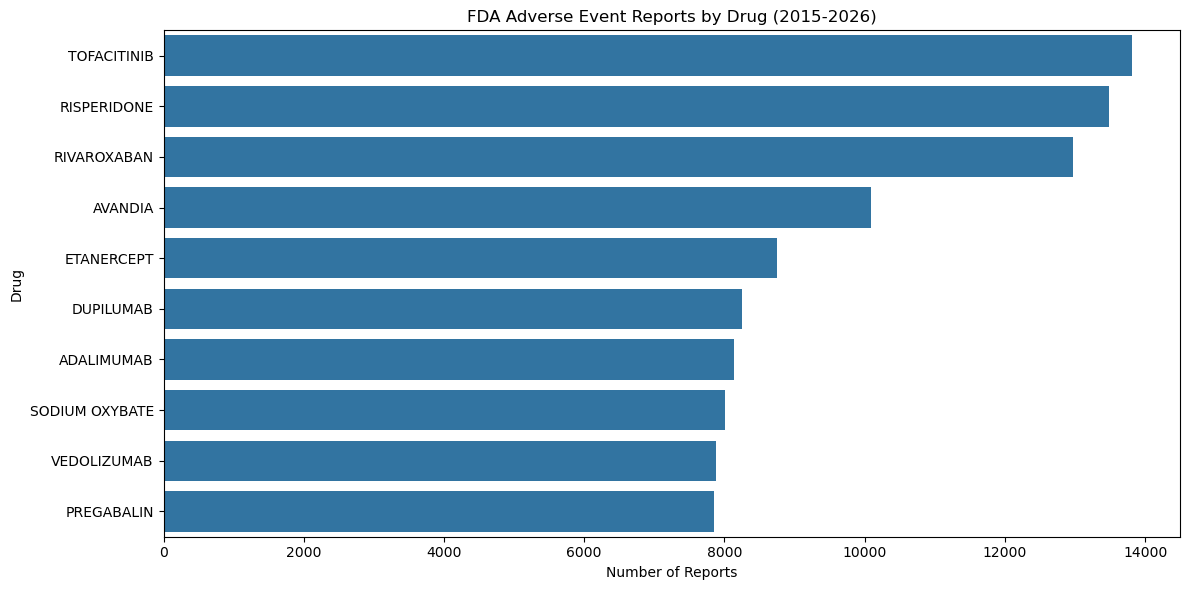

In [20]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_top, y='suspect_drug', order=top_drugs)
plt.title('FDA Adverse Event Reports by Drug (2015-2026)')
plt.xlabel('Number of Reports')
plt.ylabel('Drug')
plt.tight_layout()
plt.show()

## Fatal vs Non-Fatal Outcomes by Drug

Adverse event reports are classified by outcome severity. This chart breaks down fatal vs. non-fatal reports for the top 10 drugs. Fatal outcomes are highlighted in red to draw attention to the most serious safety signals.

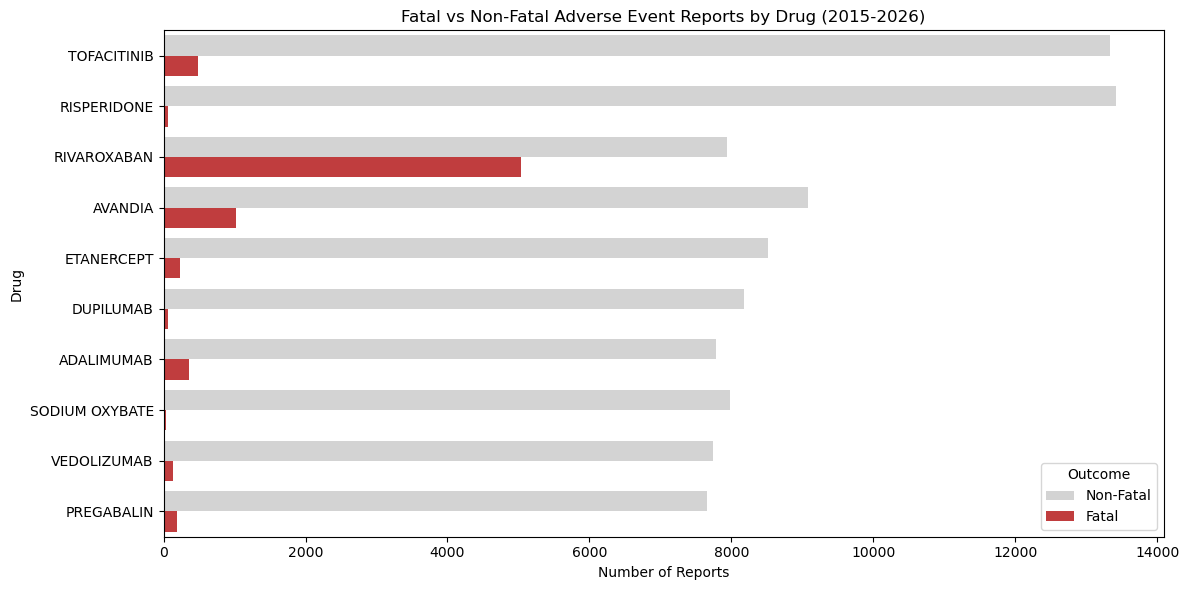

In [21]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_top, y='suspect_drug', hue='is_fatal', order=top_drugs,
              palette={False: '#d3d3d3', True: '#d62728'})
plt.title('Fatal vs Non-Fatal Adverse Event Reports by Drug (2015-2026)')
plt.xlabel('Number of Reports')
plt.ylabel('Drug')
plt.legend(title='Outcome', labels=['Non-Fatal', 'Fatal'])
plt.tight_layout()
plt.show()

## Adverse Event Reporting Trends Over Time

This chart tracks annual report counts for the top 10 drugs from 2015 to 2026. Sodium Oxybate (Xyrem), a flagship Jazza Pharmaceuticals drug for narcolepsy, is highlighted in red. All other drugs are shown in gray to reduce visual noise and direct attention to the drug of interest.

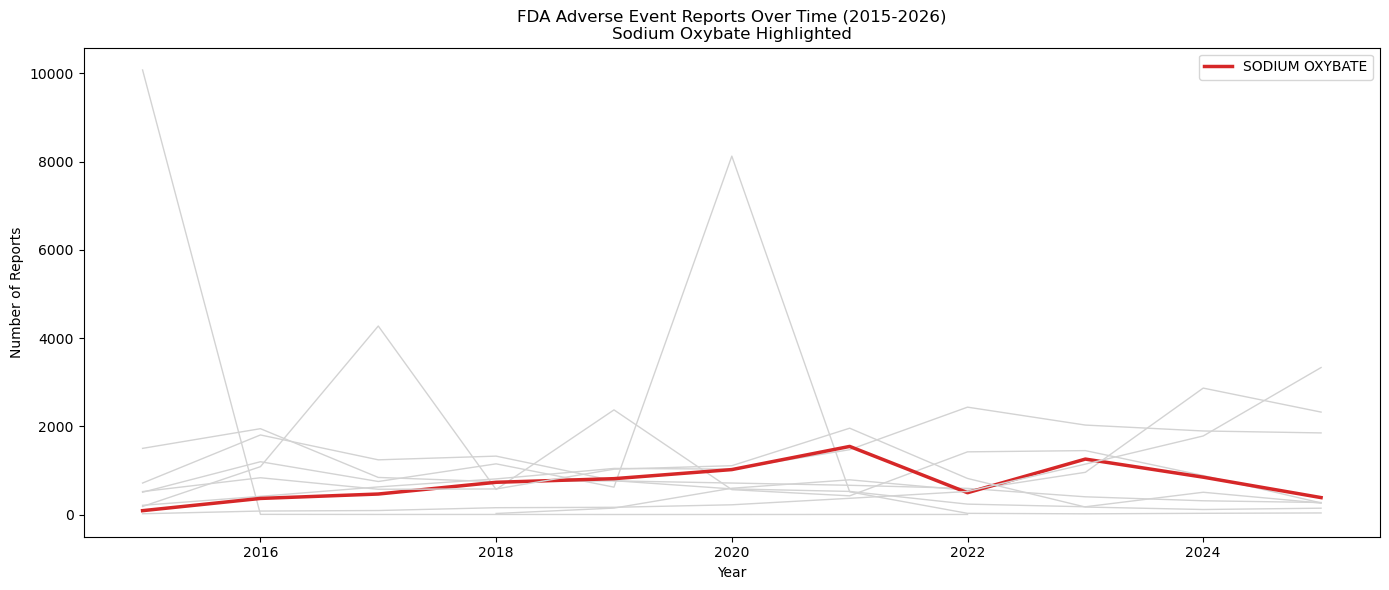

In [22]:
reports_by_year = df_top.groupby(['year', 'suspect_drug']).size().reset_index(name='report_count')

plt.figure(figsize=(14, 6))

for drug in top_drugs:
    subset = reports_by_year[reports_by_year['suspect_drug'] == drug]
    if drug == 'SODIUM OXYBATE':
        plt.plot(subset['year'], subset['report_count'], 
                color='#d62728', linewidth=2.5, label='SODIUM OXYBATE')
    else:
        plt.plot(subset['year'], subset['report_count'], 
                color='#d3d3d3', linewidth=1, label='_nolegend_')

plt.title('FDA Adverse Event Reports Over Time (2015-2026)\nSodium Oxybate Highlighted')
plt.xlabel('Year')
plt.ylabel('Number of Reports')
plt.legend()
plt.tight_layout()
plt.show()

## Top 10 Adverse Reactions for Sodium Oxybate 

This chart focuses specifically on Sodium Oxybate (Xyrem), examining which adverse reactions are most frequently reported. Sodium Oxybate is a central nervous system depressant used to treat cataplexy and excessive daytime sleepiness in narcolepsy patients. The most commonly reported reactions - including sleep apnea syndrome, suicidal ideation, and hypertension - are consisten with known safety signals for CNS medicattions and are closely monitored by the FDA.

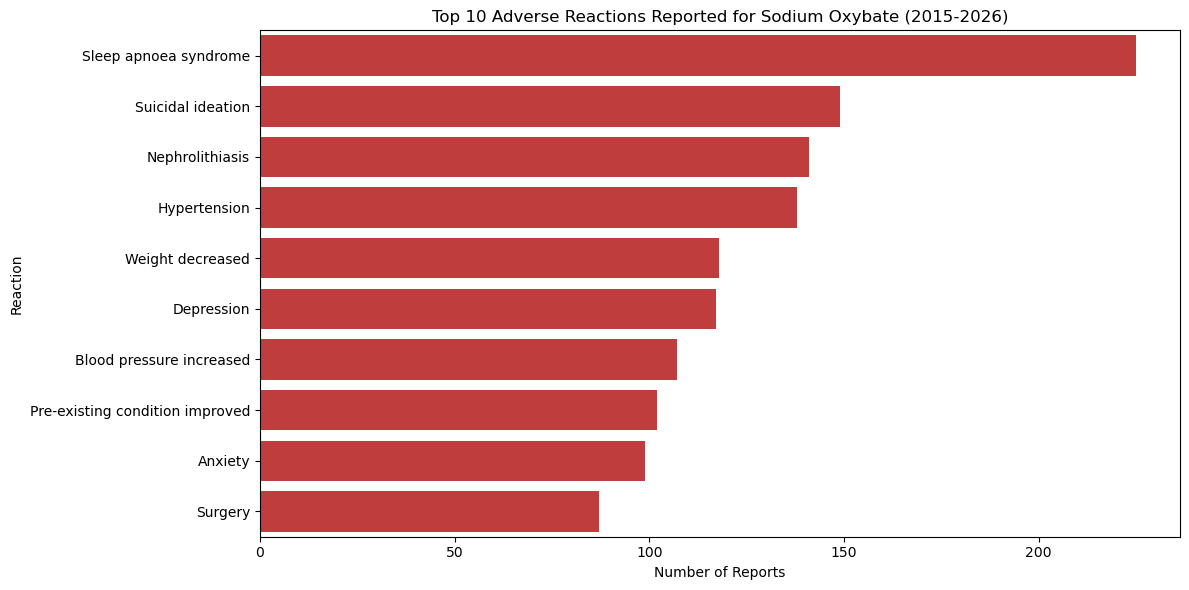

In [23]:
sodium_oxybate = df[df['suspect_drug'] == 'SODIUM OXYBATE']

top_reactions = sodium_oxybate['primary_reaction'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_reactions.values, y=top_reactions.index, color='#d62728')
plt.title('Top 10 Adverse Reactions Reported for Sodium Oxybate (2015-2026)')
plt.xlabel('Number of Reports')
plt.ylabel('Reaction')
plt.tight_layout()
plt.show()

## Key Takeaways

- Tofacitinib, Risperidone, and Rivaroxaban are the three most reported drugs in the FAERS database for this period
- Fatal outcomes represent a small but meaningful proportion of reports across all top 10 drugs
- Sodium Oxybate reporting remained relatively stable over time compared to more volatile reporting patterns seen in other drugs
- The most common adverse reactions for Sodium Oxybate align with known CNS drug safety profiles, particularly sleep-related and psychiatric effects
- Adverse event analysis is a core function of pharmacovigilance teams in pharmaceutical R&D